N= 2, τ=0.0100, Eb=1.999400, Ergotropy=1.999200, erg/Eb=0.999899983350 Variance=1.1996263896e-03
N= 4, τ=0.0100, Eb=3.998000, Ergotropy=3.997600, erg/Eb=0.999899969987 Variance=3.1992520363e-03
N= 6, τ=0.0100, Eb=5.995800, Ergotropy=5.995201, erg/Eb=0.999899956612 Variance=5.9993558302e-03
N= 8, τ=0.0100, Eb=7.992801, Ergotropy=7.992001, erg/Eb=0.999899943236 Variance=9.6004151799e-03
N=10, τ=0.0100, Eb=9.989001, Ergotropy=9.988001, erg/Eb=0.999899929860 Variance=1.4002906959e-02
N=12, τ=0.0100, Eb=11.984402, Ergotropy=11.983202, erg/Eb=0.999899916488 Variance=1.9207306900e-02
N=14, τ=0.0100, Eb=13.979002, Ergotropy=13.977603, erg/Eb=0.999899903143 Variance=2.5214087220e-02
N=16, τ=0.0100, Eb=15.972803, Ergotropy=15.971204, erg/Eb=0.999899889783 Variance=3.2023727067e-02
N=18, τ=0.0100, Eb=17.965803, Ergotropy=17.964005, erg/Eb=0.999899876402 Variance=3.9636703395e-02
N=20, τ=0.0100, Eb=19.958004, Ergotropy=19.956006, erg/Eb=0.999899863011 Variance=4.8053486867e-02


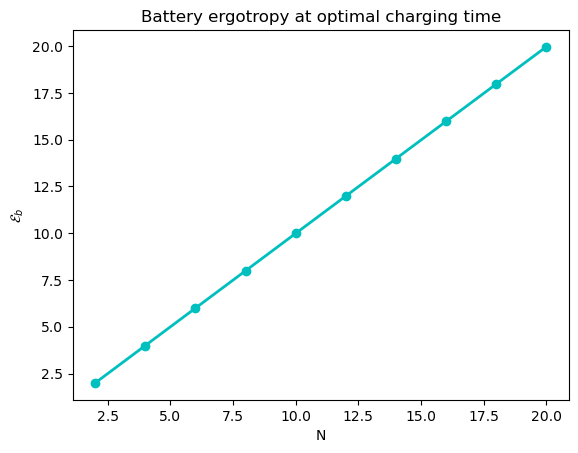

In [27]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

############
# parameters
############

N_arr = np.arange(2, 22, 2)
nmax = 130
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.0001)

######################
# collective operators
######################

def collective_ops(N):
    Sp = qt.jmat(N/2, '+')
    Sm = Sp.dag()
    Sz = qt.jmat(N/2, 'z')
    HB = Sz + (N/2)*qt.qeye(N+1)
    return Sp, Sm, HB

############################
# Tavis-Cummings Hamiltonian
############################

def tavis_cummings(N, nmax, ω, ω0, g):
    a = qt.destroy(nmax)
    Sp, Sm, HB = collective_ops(N)
    H = (ω * qt.tensor(a.dag()*a, qt.qeye(N+1)) + ω0 * qt.tensor(qt.qeye(nmax), HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm)))
    return H, HB

################
# Initial state
################

def initial_state(N, nmax, state):
    if state=="coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state=="fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.basis(N+1, 0)  
    return qt.tensor(psiA, psiB)

#########################################
# optimal charging time τ (maximum power)
#########################################

τ_list = []

for N in N_arr:
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    HB_full = qt.tensor(qt.qeye(nmax), HB)
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, tlist, e_ops=HB_full)
    EB = np.array(res.expect[0])
    power = EB / tlist

    τ_list.append(tlist[np.argmax(power)])

###########################################
# Calculation of ergotropy and fluctuations
###########################################

E_ratio, E_ergo, E_var, F_ratio, FE_ratio = [], [], [], [], []

for i, N in enumerate(N_arr):

    τ = τ_list[i]
    
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, [0, τ])
    
    rho_b = res.states[-1].proj().ptrace(1)

    E_B = qt.expect(HB, rho_b)
    
    r_vals, r_vecs = rho_b.eigenstates()
    
    idx = np.argsort(r_vals)[::-1]
    r_vals = r_vals[idx]
    r_vecs = [r_vecs[i] for i in idx]
    
    # Passive Hamiltonian constructed in the passive state's eigenbasis
    
    e_vals, e_vecs = HB.eigenstates()
    
    H_passive = sum(e_vals[i] * r_vecs[i] * r_vecs[i].dag() for i in range(len(e_vals)))

    # Ergotropy operator defined w.r.t. passive Hamiltonian
    
    E_op = HB - H_passive
    
    E_B = qt.expect(HB, rho_b)
    
    E_erg = qt.expect(E_op, rho_b)

    ΔE2 = qt.expect(E_op**2, rho_b) - E_erg**2
    
    ΔE = np.sqrt(qt.expect(E_op**2, rho_b) - E_erg**2)

    Ratio = E_erg / E_B
    
    E_ergo.append(E_erg)

    E_var.append(ΔE2)
    
    E_ratio.append(Ratio)
    
    F_ratio.append(ΔE / E_erg)

    FE_ratio.append(ΔE / E_B)

    print(f"N={N:2d}, τ={τ:.4f}, Eb={E_B:.6f}, Ergotropy={E_erg:.6f}, erg/Eb={Ratio:.12f} Variance={ΔE2:.10e}")


###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
plt.show()

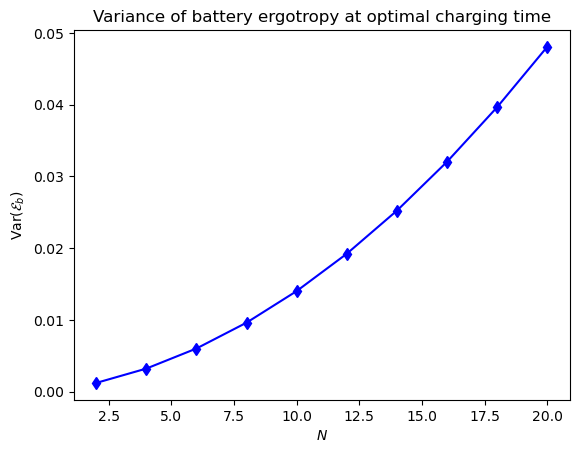

In [28]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
plt.show()

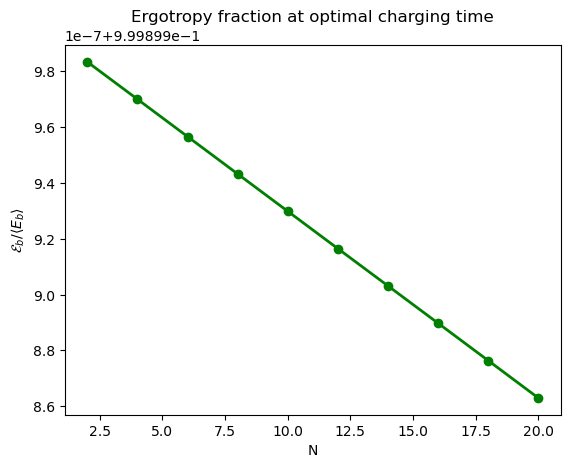

In [29]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.title("Ergotropy fraction at optimal charging time")
plt.show()

N= 2, τ=0.010, Relative Fluctuation =0.017324740767, Relative Fluctuation with Eb =0.017323008005
N= 4, τ=0.010, Relative Fluctuation =0.014148971185, Relative Fluctuation with Eb =0.014147555863
N= 6, τ=0.010, Relative Fluctuation =0.012919585917, Relative Fluctuation with Eb =0.012918293398
N= 8, τ=0.010, Relative Fluctuation =0.012259972053, Relative Fluctuation with Eb =0.012258745360
N=10, τ=0.010, Relative Fluctuation =0.011847603307, Relative Fluctuation with Eb =0.011846417716
N=12, τ=0.010, Relative Fluctuation =0.011565391932, Relative Fluctuation with Eb =0.011564234427
N=14, τ=0.010, Relative Fluctuation =0.011360277248, Relative Fluctuation with Eb =0.011359140120
N=16, τ=0.010, Relative Fluctuation =0.011204649897, Relative Fluctuation with Eb =0.011203528197
N=18, τ=0.010, Relative Fluctuation =0.011082700748, Relative Fluctuation with Eb =0.011081591108
N=20, τ=0.010, Relative Fluctuation =0.010984716072, Relative Fluctuation with Eb =0.010983616095


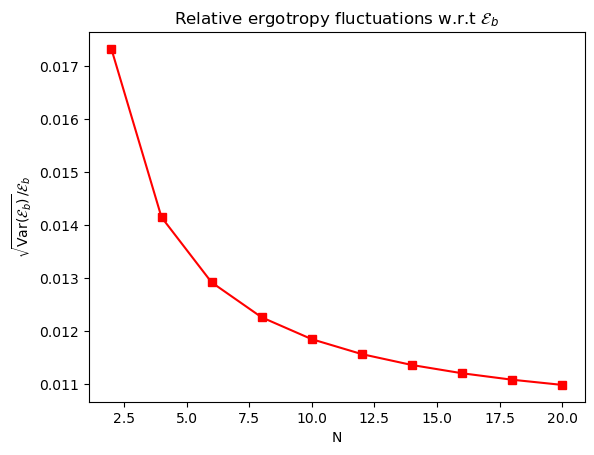

In [30]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.3f}, Relative Fluctuation ={F_ratio[idx]:.12f}, Relative Fluctuation with Eb ={FE_ratio[idx]:.12f}")


######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.show()

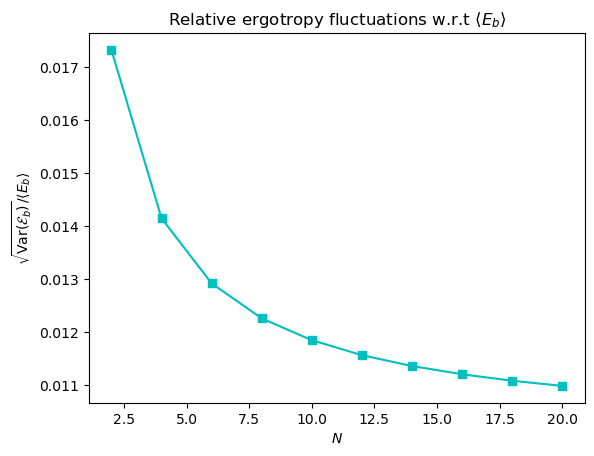

In [31]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='c')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
plt.show()